# Breast Cancer Classification with KNN

**Diagnosing breast cancer using K-Nearest Neighbors with pipeline optimization**

---

| Detail | Value |
|--------|-------|
| **Dataset** | Breast Cancer Wisconsin Dataset |
| **Techniques** | KNN, Pipeline, Feature Selection, StandardScaler, Cross-Validation |
| **Author** | Ahmed Alnahrawy |



## 1. Setup & Imports

Import libraries and configure the ML pipeline.


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, chi2,f_regression
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score,roc_curve


## 2. Data Loading & Exploration

Load the Breast Cancer dataset and explore feature relationships.


In [8]:
df= pd.read_csv('../data/Breast_Cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [9]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [11]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:


## 3. Feature Engineering & Preprocessing

Select features, encode labels, and scale data.


<Axes: xlabel='count', ylabel='diagnosis'>

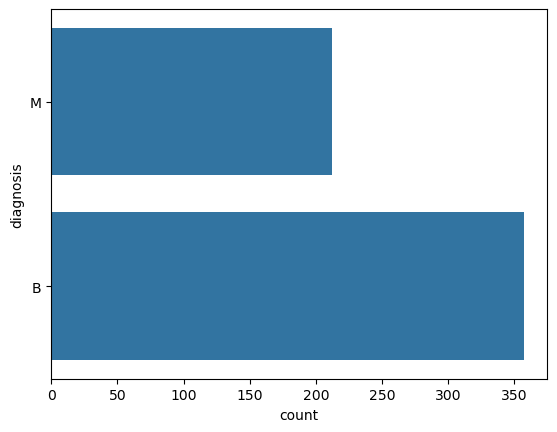

In [12]:
sns.countplot(df['diagnosis'])

In [13]:
df.drop(columns=['id','Unnamed: 32'],axis=1,inplace=True)

In [14]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<Axes: >

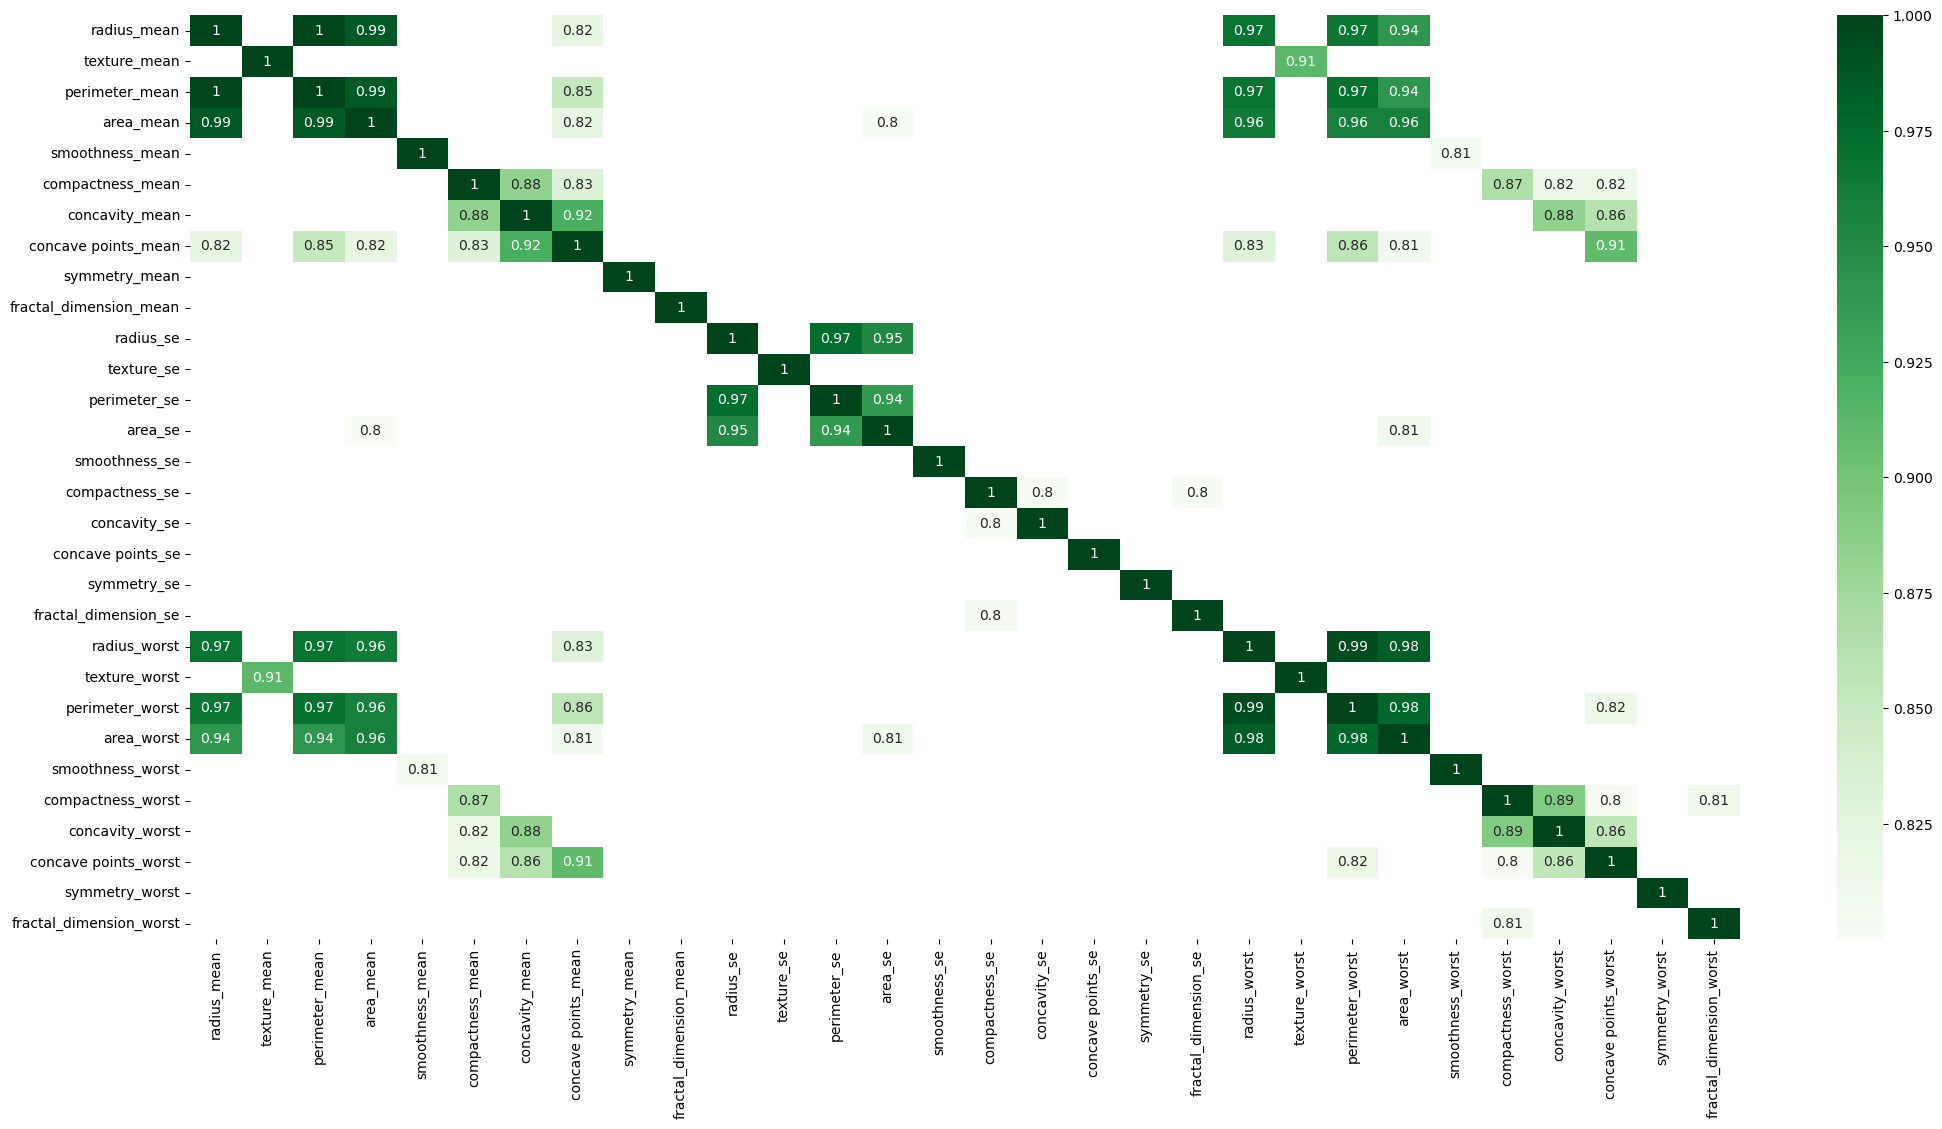

In [15]:
plt.figure(figsize=(25,12))
corr=df.drop("diagnosis",axis=1).corr()
kot = corr[corr>=.8]
sns.heatmap(kot, annot=True, cmap="Greens")


In [16]:
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
df['diagnosis']

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [17]:
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64


## 4. KNN Model Training & Tuning

Train KNN classifier, optimize K value, and evaluate results.


In [18]:
x=df.drop("diagnosis",axis=1)
y=df["diagnosis"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_val,y_train,y_val=train_test_split(x_train, y_train,test_size=0.1,random_state=42)

In [19]:
pipe = Pipeline([('select',SelectKBest(score_func=f_regression)),
('scale',MinMaxScaler())
,('knn',KNeighborsClassifier())
])

In [20]:
params={
    'select__k':[5,10,15,20,25,30],
    'knn__n_neighbors':[3,5,7,9,11],
    'knn__p':[1,2]
}

In [21]:
grid_search=GridSearchCV(pipe,param_grid=params,cv=5,scoring='accuracy')
grid_search.fit(x_train,y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'knn__n_neighbors': [3, 5, ...], 'knn__p': [1, 2], 'select__k': [5, 10, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,score_func,<function f_r...002236628CCC0>


In [22]:
grid_search.best_params_

{'knn__n_neighbors': 9, 'knn__p': 2, 'select__k': 20}

In [23]:
best_model=grid_search.best_estimator_

In [24]:
y_train_pred=best_model.predict(x_train)

In [25]:
y_val_pred=best_model.predict(x_val)

In [26]:
y_pred=best_model.predict(x_test)

accuracy= 96.49122807017544 %
F1cscore= 95.34883720930233 %
precision= 95.34883720930233 %
recall= 95.34883720930233 %


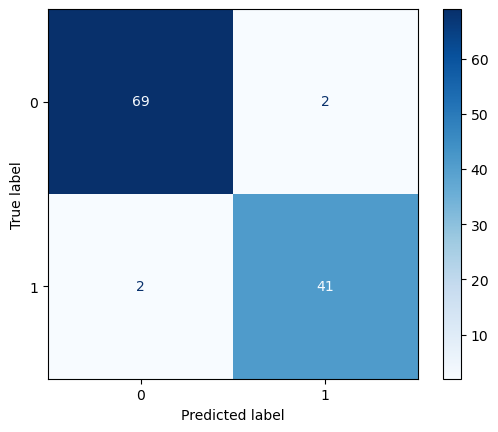

In [27]:
acc=accuracy_score(y_test,y_pred)
print("accuracy=",acc*100,'%')
f1=f1_score(y_test,y_pred)
print("F1cscore=",f1*100,'%')
pre=precision_score(y_test,y_pred)
print("precision=",pre*100,'%')
rec=recall_score(y_test,y_pred)
print("recall=",rec*100,'%')
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()


accuracy= 97.82608695652173 %
F1cscore= 96.96969696969697 %
precision= 94.11764705882352 %
recall= 100.0 %


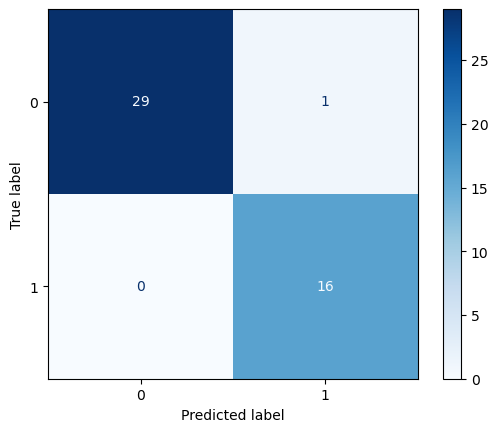

In [28]:
acc1=accuracy_score(y_val,y_val_pred)
print("accuracy=",acc1*100,'%')
f11=f1_score(y_val,y_val_pred)
print("F1cscore=",f11*100,'%')
pre1=precision_score(y_val,y_val_pred)
print("precision=",pre1*100,'%')
rec1=recall_score(y_val,y_val_pred)
print("recall=",rec1*100,'%')
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()



---

## Summary

This notebook demonstrated knn, pipeline, feature selection, standardscaler, cross-validation techniques applied to the Breast Cancer Wisconsin Dataset.

**Author:** Ahmed Alnahrawy | [GitHub](https://github.com/Ahmed-Na7rawy)
